Imports

In [36]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from sklearn.inspection import DecisionBoundaryDisplay


# Question 1

In [37]:
tp = 35
tn = 930
fp = 20
fn = 15
total = 1000

acuracy = (tp + tn) / total
print(f"acuracy :{acuracy}")

precision = (tp) / (tp + fp)
print(f"precision :{precision}")

recall = tp / (tp + fn)
print(f"recall :{recall}")

f1 = (2 * precision * recall) / (precision + recall)
print(f"f1 :{f1}")

acuracy :0.965
precision :0.6363636363636364
recall :0.7
f1 :0.6666666666666666


# Question 2

score : 0.9473684210526315
precision_score : 0.9459459459459459
recall_score : 0.9722222222222222

f1_score : 0.958904109589041

confusion_matrix : [[38  4]
 [ 2 70]]

classification_report :
               precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



E:\Maktab-145\maktab_kernel\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


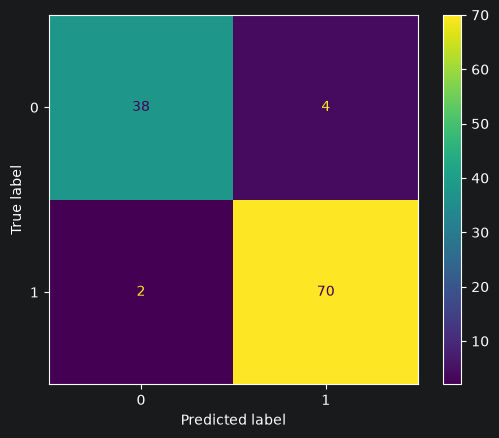

classification_report thershold = 0.3 :
               precision    recall  f1-score   support

           0       1.00      0.86      0.92        42
           1       0.92      1.00      0.96        72

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

classification_report thershold = 0.5 :
               precision    recall  f1-score   support

           0       0.95      0.90      0.93        42
           1       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

classification_report thershold = 0.7 :
               precision    recall  f1-score   support

           0       0.91      0.93      0.92        42
           1       0.96      0.94      0.95        72

    accuracy                           0.94       114
   ma

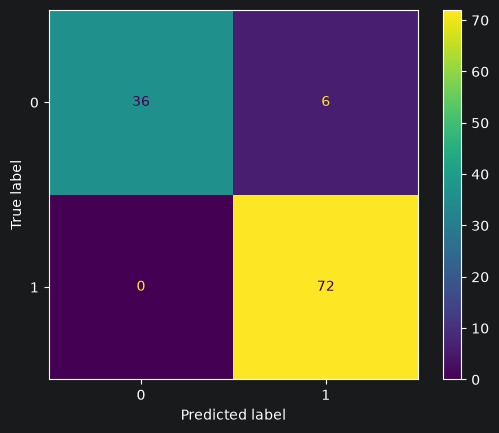

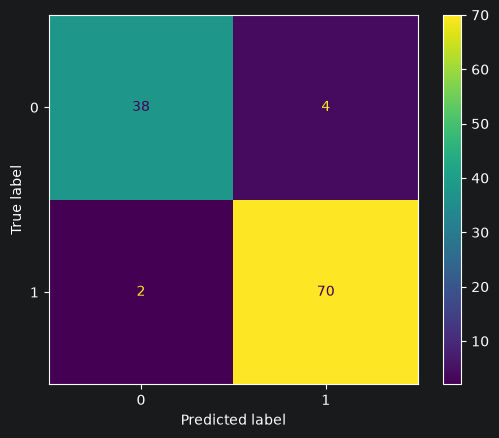

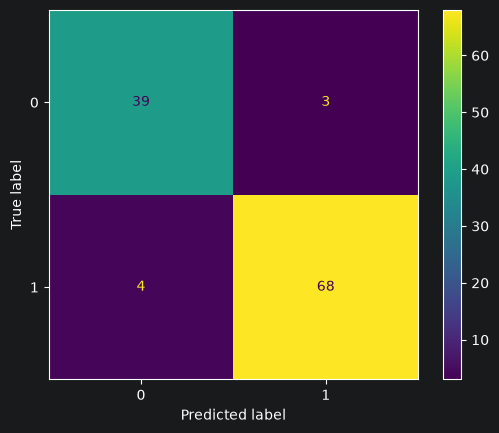

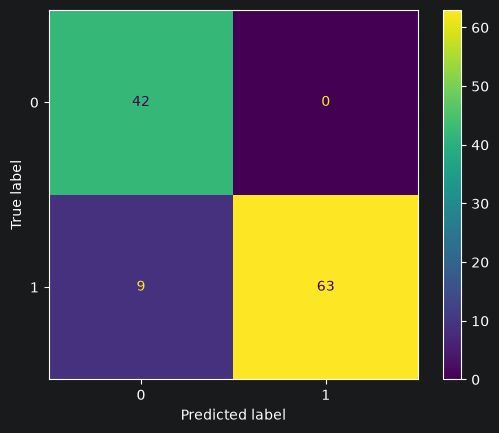

In [38]:

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# X, y = load_breast_cancer(return_X_y=True)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2, stratify=y
)

model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(f"score : {model.score(x_test,y_test)}")
print(f"precision_score : {precision_score(y_test,y_pred)}")
print(f"recall_score : {recall_score(y_test,y_pred)}\n")
print(f"f1_score : {f1_score(y_test,y_pred)}\n")
print(f"confusion_matrix : {confusion_matrix(y_test,y_pred)}\n")

print(f"classification_report :\n {classification_report(y_test,y_pred)}")

cm = confusion_matrix(y_test, y_pred)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
dsp.plot()
plt.show()


y_prob = model.predict_proba(x_test)[:, 1]

thersholds = [0.3, 0.5, 0.7]
ther_shold3 = y_prob > 0.3
ther_shold5 = y_prob > 0.5
ther_shold7 = y_prob > 0.7
ther_shold9 = y_prob > 0.9

print(
    f"classification_report thershold = 0.3 :\n {classification_report(y_test,ther_shold3)}"
)
print(
    f"classification_report thershold = 0.5 :\n {classification_report(y_test,ther_shold5)}"
)
print(
    f"classification_report thershold = 0.7 :\n {classification_report(y_test,ther_shold7)}"
)
print(
    f"classification_report thershold = 0.9 :\n {classification_report(y_test,ther_shold9)}"
)

cm = confusion_matrix(y_test, ther_shold3)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
dsp.plot()
plt.show()

cm = confusion_matrix(y_test, ther_shold5)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
dsp.plot()
plt.show()

cm = confusion_matrix(y_test, ther_shold7)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
dsp.plot()
plt.show()

cm = confusion_matrix(y_test, ther_shold9)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
dsp.plot()
plt.show()

# Question 3

acc_t_1 :0.70125
acc_1 test: 0.725


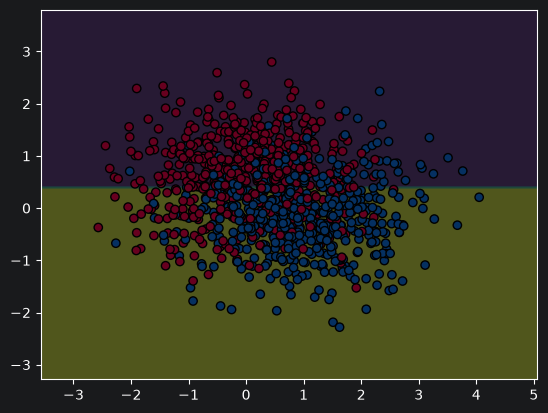

acc_t_5 :0.78375
acc_5 test: 0.735


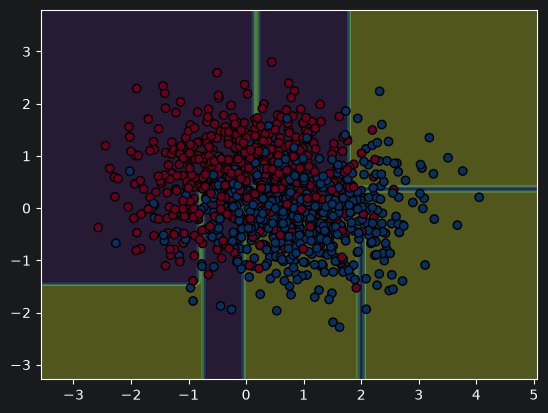

acc_nolimit_t :1.0
acc_nolimit_test: 0.66


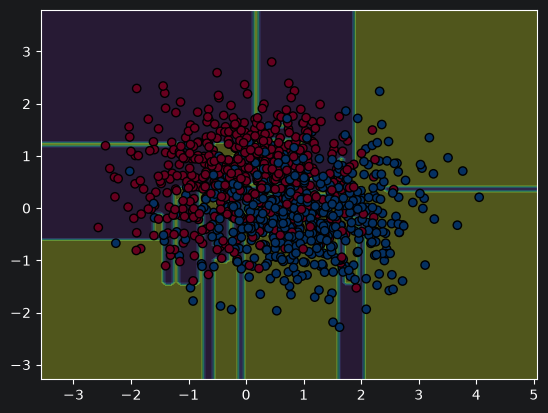

,Acc train,Acc test
max depth 1,0.70125,0.725
max depth 5,0.78375,0.735
Unlimited,1.00000,0.660


In [39]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

X, y = make_moons(n_samples=1000, noise=0.7, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=49, stratify=y
)

tree_1 = DecisionTreeClassifier(max_depth=1, random_state=42)
tree_1.fit(X_train, y_train)
acc_t_1 = tree_1.score(X_train, y_train)
acc_1 = tree_1.score(X_test, y_test)
print(f"acc_t_1 :{acc_t_1}")
print(f"acc_1 test: {acc_1}")
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots()

DecisionBoundaryDisplay.from_estimator(
    tree_1, X, response_method="predict", alpha=0.3, ax=ax
)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k")
plt.show()

tree_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_5.fit(X_train, y_train)
acc_t_5 = tree_5.score(X_train, y_train)
acc_5 = tree_5.score(X_test, y_test)
print(f"acc_t_5 :{acc_t_5}")
print(f"acc_5 test: {acc_5}")
##################
fig, ax = plt.subplots()

DecisionBoundaryDisplay.from_estimator(
    tree_5, X, response_method="predict", alpha=0.3, ax=ax
)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k")
plt.show()


tree_nolimit = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_nolimit.fit(X_train, y_train)
acc_nolimit_t = tree_nolimit.score(X_train, y_train)
acc_nolimit = tree_nolimit.score(X_test, y_test)
print(f"acc_nolimit_t :{acc_nolimit_t}")
print(f"acc_nolimit_test: {acc_nolimit}")
################
fig, ax = plt.subplots()

DecisionBoundaryDisplay.from_estimator(
    tree_nolimit, X, response_method="predict", alpha=0.3, ax=ax
)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolor="k")
plt.show()


df = pd.DataFrame(
    index=["max depth 1", "max depth 5", "Unlimited"], columns=["Acc train", "Acc test"]
)
df["Acc train"] = [acc_t_1, acc_t_5, acc_nolimit_t]
df["Acc test"] = [acc_1, acc_5, acc_nolimit]

display(df)

# Question 4

In [40]:
load_cancer = load_breast_cancer(as_frame=True).frame
load_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [43]:
X_train,X_test,y_train,y_test = train_test_split(load_cancer.iloc[:,:-1],load_cancer.iloc[:,-1],test_size=0.2,random_state=42,stratify=load_cancer.iloc[:,-1])
X_train,X_valid,y_train,y_valid = train_test_split(X_train, y_train, test_size=0.25,random_state=42,stratify=y_train)

In [44]:
tree_1 = DecisionTreeClassifier(max_depth=1)
tree_1.fit(X_train, y_train)
tree_2 = DecisionTreeClassifier(max_depth=2)
tree_2.fit(X_train, y_train)
tree_3 = DecisionTreeClassifier(max_depth=3)
tree_3.fit(X_train, y_train)
tree_5 =DecisionTreeClassifier(max_depth=5)
tree_5.fit(X_train, y_train)
tree_10 =DecisionTreeClassifier(max_depth=10)
tree_10.fit(X_train, y_train)
tree_free = DecisionTreeClassifier()

In [53]:
pred_1 = tree_1.predict(X_valid)
pred_2 = tree_2.predict(X_valid)
pred_3 = tree_3.predict(X_valid)
pred_5 = tree_5.predict(X_valid)
pred_10 = tree_10.predict(X_valid)

acc_train_1 = tree_1.score(X_train, y_train)
acc_train_2 = tree_2.score(X_train, y_train)
acc_train_3 = tree_3.score(X_train, y_train)
acc_train_5 = tree_5.score(X_train, y_train)
acc_train_10 =tree_10.score(X_train,y_train)

acc_validation_1 = tree_1.score(X_valid,y_valid)
acc_validation_2 = tree_2.score(X_valid,y_valid)
acc_validation_3 = tree_3.score(X_valid,y_valid)
acc_validation_5 = tree_5.score(X_valid,y_valid)
acc_validation_10 = tree_10.score(X_valid,y_valid)
print(f'{"acc_train_1":<20}: {acc_train_1:>6.2f}')
print(f'{"acc_validation_1":<20}: {acc_validation_1:>6.2f}')
print("-" * 11)

print(f'{"acc_train_2":<20}: {acc_train_2:>6.2f}')
print(f'{"acc_validation_2":<20}: {acc_validation_2:>6.2f}')
print("-" * 11)

print(f'{"acc_train_3":<20}: {acc_train_3:>6.2f}')
print(f'{"acc_validation_3":<20}: {acc_validation_3:>6.2f}')
print("-" * 11)

print(f'{"acc_train_5":<20}: {acc_train_5:>6.2f}')
print(f'{"acc_validation_5":<20}: {acc_validation_5:>6.2f}')
print("-" * 11)

print(f'{"acc_train_10":<20}: {acc_train_10:>6.2f}')
print(f'{"acc_validation_10":<20}: {acc_validation_10:>6.2f}')



acc_train_1         :   0.93
acc_validation_1    :   0.89
-----------
acc_train_2         :   0.97
acc_validation_2    :   0.95
-----------
acc_train_3         :   0.97
acc_validation_3    :   0.95
-----------
acc_train_5         :   1.00
acc_validation_5    :   0.96
-----------
acc_train_10        :   1.00
acc_validation_10   :   0.95


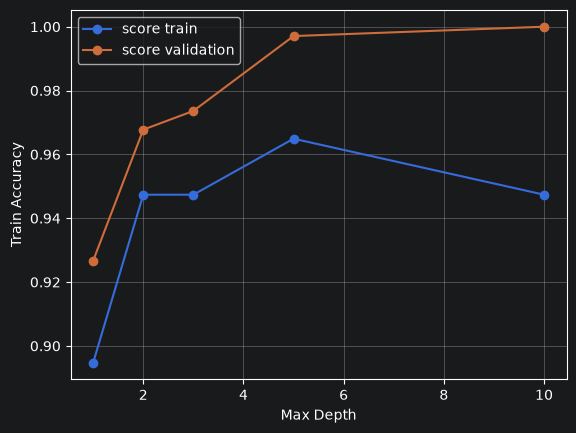

In [63]:
results_df = pd.DataFrame(
    {
        "train_accuracy": [
            acc_train_1,
            acc_train_2,
            acc_train_3,
            acc_train_5,
            acc_train_10,
        ],
        "validation_accuracy": [
            acc_validation_1,
            acc_validation_2,
            acc_validation_3,
            acc_validation_5,
            acc_validation_10,
        ],
        "max_depth":[1, 2, 3, 5, 10]
    }
)

plt.plot(results_df["max_depth"],results_df["validation_accuracy"],marker="o",label="score train")
plt.ylabel("Validation Accuracy")
plt.xlabel("Max Depth")
plt.plot(results_df["max_depth"],results_df["train_accuracy"],marker="o",label="score validation")
plt.ylabel("Training Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Train Accuracy")
plt.xlabel("Max Depth")
plt.grid()
plt.legend()
plt.show()

